# Week 9 — Group-wise SHAP Analysis
## Bias Analysis in ML Models using Explainable AI

**Project:** Bias Analysis in ML Models using Explainable AI  
**Notebook:** week9_groupwise_shap.ipynb  
**Supervisor:** Prof. Saiful Islam  

---

### What this notebook does

Week 8 (SHAP) showed that `relationship` is the single dominant feature in DT Balanced globally, and that it caused Individual C's false negative specifically. But a global average can hide group-level patterns — maybe `relationship` is dominant *for males* but something else drives predictions *for females*.

This notebook splits the test set by demographic group and computes SHAP values separately for each group. The goal is to answer whether the model reasons differently about different groups — or whether the same features dominate across all groups.

**Parts covered:**
1. Group-wise SHAP by Sex (Male vs Female)
2. Group-wise SHAP by Race (5 groups)
3. Intersectional Group-wise SHAP (Sex × Race)
4. Directional (signed) SHAP analysis
5. Top-5 feature ranking comparison table

**SHAP drift is NOT covered here** — that is a separate notebook.

---

### Hypotheses going in (from Week 8 findings)

- **H1:** `relationship` will dominate for both male and female groups in DT Balanced, but with different *direction* — positive for males (Husband), negative or neutral for females who are Not-in-family.
- **H2:** `sex` will appear explicitly as a top feature for LR Balanced in the female group but not male.
- **H3:** The relationship-driven pattern will be consistent across racial groups — it is a structural feature of the dataset, not specific to any racial subgroup.
- **H4:** Intersectional analysis will show Female × non-White groups face compounded disadvantage — both the relationship penalty and potentially different feature rankings.

---
## 0. Imports and Setup

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import warnings

warnings.filterwarnings('ignore')
shap.initjs()

# Consistent plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Imports complete.")

Imports complete.


---
## 1. Load Saved Artefacts from Week 6/7

We load the exact test set and models saved in week6.ipynb/week7.ipynb so results are directly comparable.

In [18]:
# Load models
dt_bal  = joblib.load('dt_balanced_model.pkl')
lr_bal  = joblib.load('lr_balanced_model.pkl')

# Load test features and labels
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').squeeze()  # Series

# Load sensitive attributes for the test set
sensitive = pd.read_csv('sensitive_test.csv')  # has 'sex', 'race' columns

print(f"Test set size: {X_test.shape}")
print(f"Sex distribution:\n{sensitive['sex'].value_counts()}")
print(f"\nRace distribution:\n{sensitive['race'].value_counts()}")

Test set size: (6033, 12)
Sex distribution:
sex
Male      4065
Female    1968
Name: count, dtype: int64

Race distribution:
race
White                 5186
Black                  559
Asian-Pac-Islander     186
Amer-Indian-Eskimo      64
Other                   38
Name: count, dtype: int64


---
## 2. Compute SHAP Values — Full Test Set

We compute SHAP values once over the full test set, then slice by group. This is more efficient than running separate SHAP explainers per group and produces numerically consistent values.

In [19]:
# --- DT Balanced: TreeExplainer ---
explainer_dt = shap.TreeExplainer(dt_bal)
shap_values_dt = explainer_dt.shap_values(X_test)

# TreeExplainer returns a list [class0, class1] for binary classifiers
# We want class 1 (>50K) values
# Handle all SHAP return formats
if isinstance(shap_values_dt, list):
    sv_dt = shap_values_dt[1]          # old format: list of [class0, class1]
elif shap_values_dt.ndim == 3:
    sv_dt = shap_values_dt[:, :, 1]    # new format: (samples, features, classes)
else:
    sv_dt = shap_values_dt             # single array format

print(f'DT SHAP values shape: {sv_dt.shape}')
print(f'Expected shape: ({X_test.shape[0]}, {X_test.shape[1]})')

DT SHAP values shape: (6033, 12)
Expected shape: (6033, 12)


In [20]:
# --- LR Balanced: LinearExplainer ---
explainer_lr = shap.LinearExplainer(lr_bal, X_test)
shap_values_lr = explainer_lr.shap_values(X_test)

# LinearExplainer returns a single array for binary classifiers
sv_lr = shap_values_lr
print(f"LR SHAP values shape: {sv_lr.shape}")

LR SHAP values shape: (6033, 12)


In [21]:
# Wrap into DataFrames for easy group-slicing
shap_dt_df = pd.DataFrame(sv_dt, columns=X_test.columns, index=X_test.index)
shap_lr_df = pd.DataFrame(sv_lr, columns=X_test.columns, index=X_test.index)

# Reset sensitive index to align
sensitive = sensitive.reset_index(drop=True)
X_test    = X_test.reset_index(drop=True)
shap_dt_df = shap_dt_df.reset_index(drop=True)
shap_lr_df = shap_lr_df.reset_index(drop=True)

# Build intersectional column
sensitive['sex_race'] = sensitive['sex'].astype(str) + '_' + sensitive['race'].astype(str)

print("DataFrames aligned. Intersectional groups:")
print(sensitive['sex_race'].value_counts())

DataFrames aligned. Intersectional groups:
sex_race
Male_White                   3596
Female_White                 1590
Male_Black                    280
Female_Black                  279
Male_Asian-Pac-Islander       123
Female_Asian-Pac-Islander      63
Male_Amer-Indian-Eskimo        41
Male_Other                     25
Female_Amer-Indian-Eskimo      23
Female_Other                   13
Name: count, dtype: int64


---
## 3. Helper Functions

One function computes group-wise mean |SHAP| and mean signed SHAP. Another plots the side-by-side comparison bar chart. Defined once, reused across all parts.

In [22]:
def compute_group_shap(shap_df, group_mask, top_n=10):
    """
    Given a SHAP DataFrame and a boolean mask for a group,
    return:
      - mean_abs: mean absolute SHAP per feature (importance)
      - mean_signed: mean signed SHAP per feature (direction)
    Both sorted by mean_abs descending, top_n features.
    """
    subset = shap_df[group_mask]
    mean_abs    = subset.abs().mean().sort_values(ascending=False).head(top_n)
    mean_signed = subset.mean()[mean_abs.index]  # keep same order
    return mean_abs, mean_signed


def plot_group_comparison(group_data, title, model_name, top_n=8, figsize=(13, 5)):
    """
    group_data: dict of {group_label: (mean_abs_series, mean_signed_series)}
    Plots mean |SHAP| side by side for all groups.
    """
    n_groups = len(group_data)
    fig, axes = plt.subplots(1, n_groups, figsize=figsize, sharey=False)
    if n_groups == 1:
        axes = [axes]

    palette = plt.cm.tab10.colors

    for ax, (label, (mean_abs, _)), color in zip(axes, group_data.items(), palette):
        features = mean_abs.index[:top_n][::-1]  # reverse for horizontal bar
        values   = mean_abs.values[:top_n][::-1]
        bars = ax.barh(features, values, color=color, alpha=0.85)
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_xlabel('Mean |SHAP|')
        ax.axvline(0, color='black', linewidth=0.7)

    fig.suptitle(f'{title} — {model_name}', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_signed_comparison(group_data, title, model_name, top_n=8, figsize=(13, 5)):
    """
    Plots mean SIGNED SHAP (direction analysis) side by side.
    Green = pushes toward >50K, Red = pushes toward <=50K.
    """
    n_groups = len(group_data)
    fig, axes = plt.subplots(1, n_groups, figsize=figsize, sharey=False)
    if n_groups == 1:
        axes = [axes]

    for ax, (label, (mean_abs, mean_signed)) in zip(axes, group_data.items()):
        features = mean_abs.index[:top_n][::-1]
        values   = mean_signed[features].values
        colors   = ['#2ecc71' if v >= 0 else '#e74c3c' for v in values]
        ax.barh(features, values, color=colors, alpha=0.85)
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_xlabel('Mean Signed SHAP')
        ax.axvline(0, color='black', linewidth=1.0)

    fig.suptitle(f'{title} — Direction Analysis ({model_name})', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def build_ranking_table(group_data, top_n=5):
    """
    Returns a DataFrame showing top-N feature rankings across all groups side by side.
    Columns: Rank | Group1_feature | Group1_|SHAP| | Group2_feature | ...
    """
    records = {'Rank': list(range(1, top_n+1))}
    for label, (mean_abs, _) in group_data.items():
        top_features = mean_abs.index[:top_n].tolist()
        top_values   = mean_abs.values[:top_n].tolist()
        records[f'{label} Feature']    = top_features
        records[f'{label} |SHAP|']     = [f"{v:.4f}" for v in top_values]
    return pd.DataFrame(records)

print("Helper functions defined.")

Helper functions defined.


---
## Part 1 — Group-wise SHAP by Sex

**Hypothesis:** `relationship` dominates for males (Husband → +SHAP). For females, it still dominates but in the negative direction for those coded as Not-in-family. The model reasons via the same *feature* for both sexes but with structurally different *values*.

In [23]:
# --- Decode sex labels (0 = Female, 1 = Male in label encoding) ---
# Adjust these values if your encoding differs
male_mask   = (sensitive['sex'] == 'Male')
female_mask = (sensitive['sex'] == 'Female')

print(f"Male test samples:   {male_mask.sum()}")
print(f"Female test samples: {female_mask.sum()}")

Male test samples:   4065
Female test samples: 1968


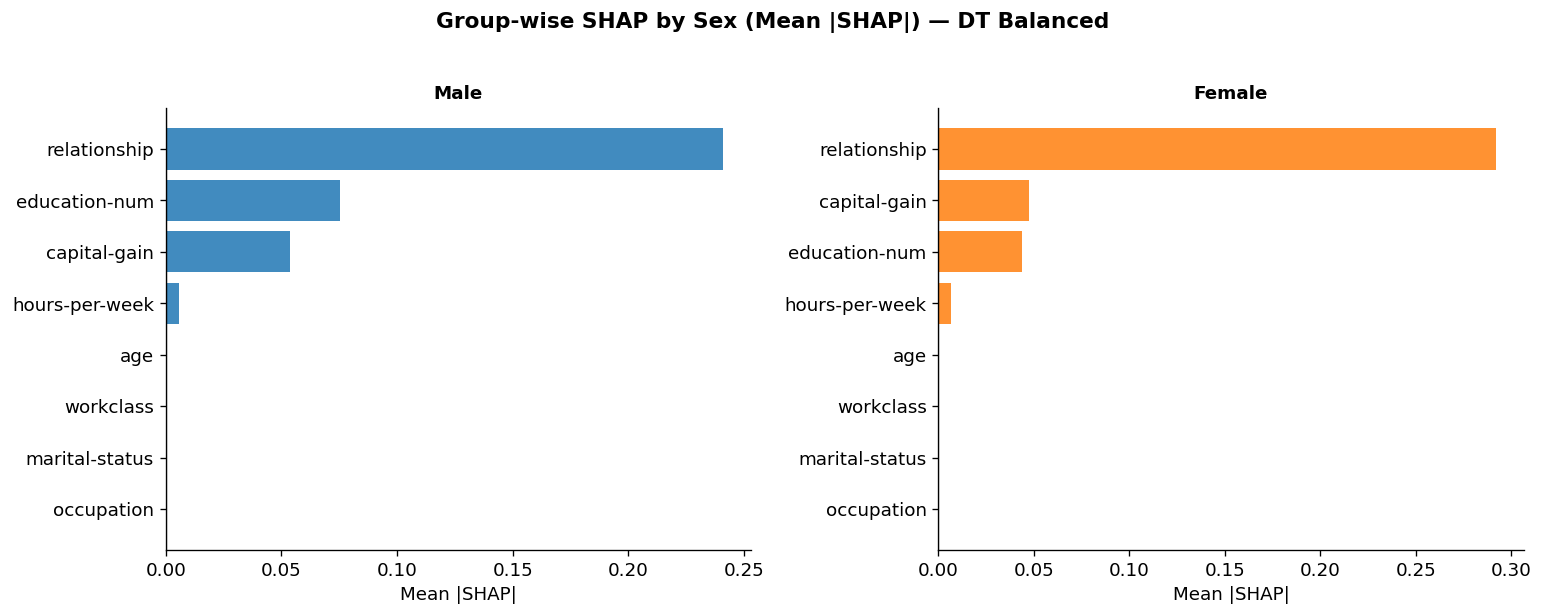

In [24]:
# --- DT Balanced: Group-wise mean |SHAP| by sex ---
sex_groups_dt = {
    'Male'   : compute_group_shap(shap_dt_df, male_mask),
    'Female' : compute_group_shap(shap_dt_df, female_mask)
}

plot_group_comparison(sex_groups_dt, 'Group-wise SHAP by Sex (Mean |SHAP|)', 'DT Balanced')

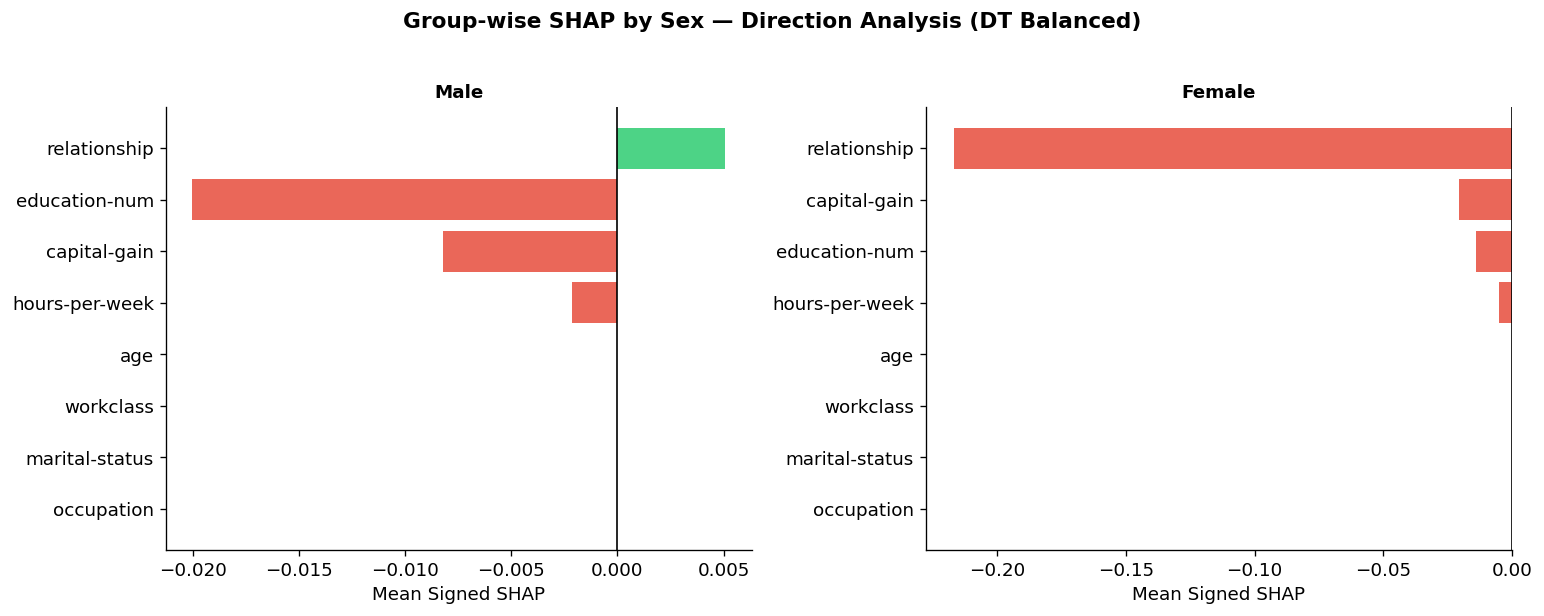

In [25]:
# --- DT Balanced: Signed SHAP by sex (direction analysis) ---
plot_signed_comparison(sex_groups_dt, 'Group-wise SHAP by Sex', 'DT Balanced')

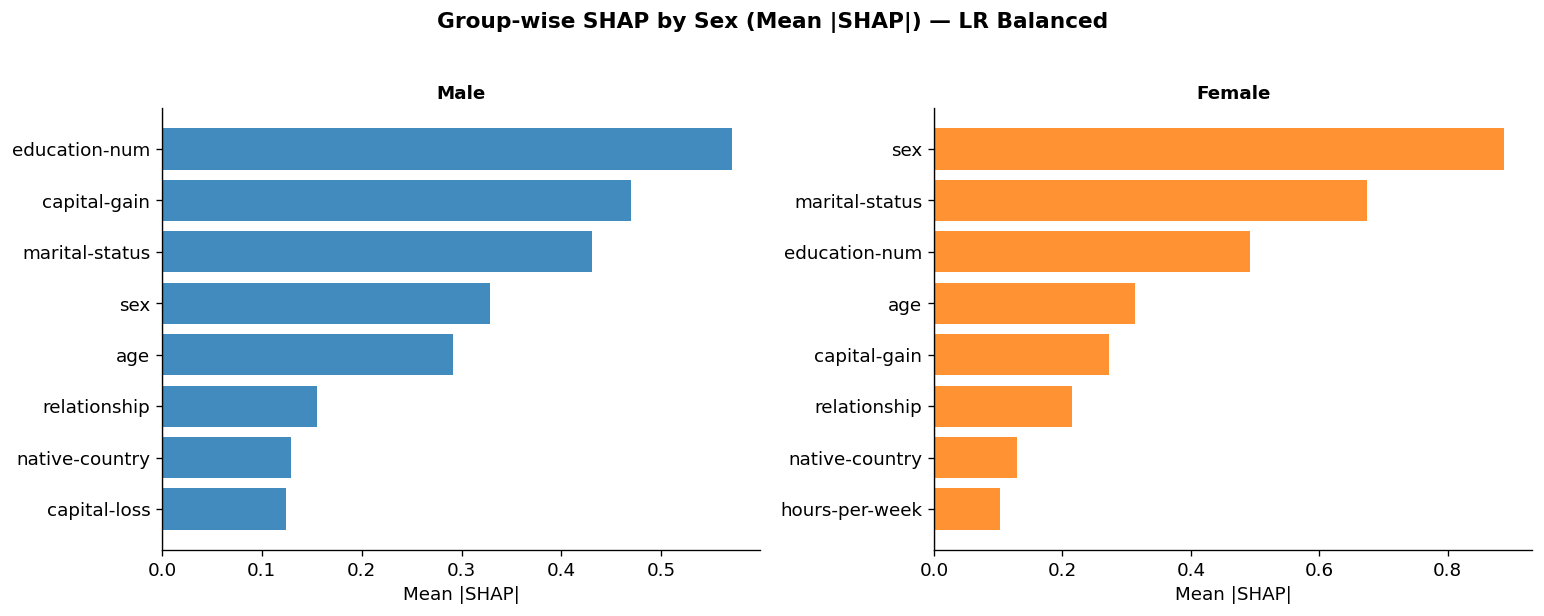

In [26]:
# --- LR Balanced: Group-wise mean |SHAP| by sex ---
sex_groups_lr = {
    'Male'   : compute_group_shap(shap_lr_df, male_mask),
    'Female' : compute_group_shap(shap_lr_df, female_mask)
}

plot_group_comparison(sex_groups_lr, 'Group-wise SHAP by Sex (Mean |SHAP|)', 'LR Balanced')

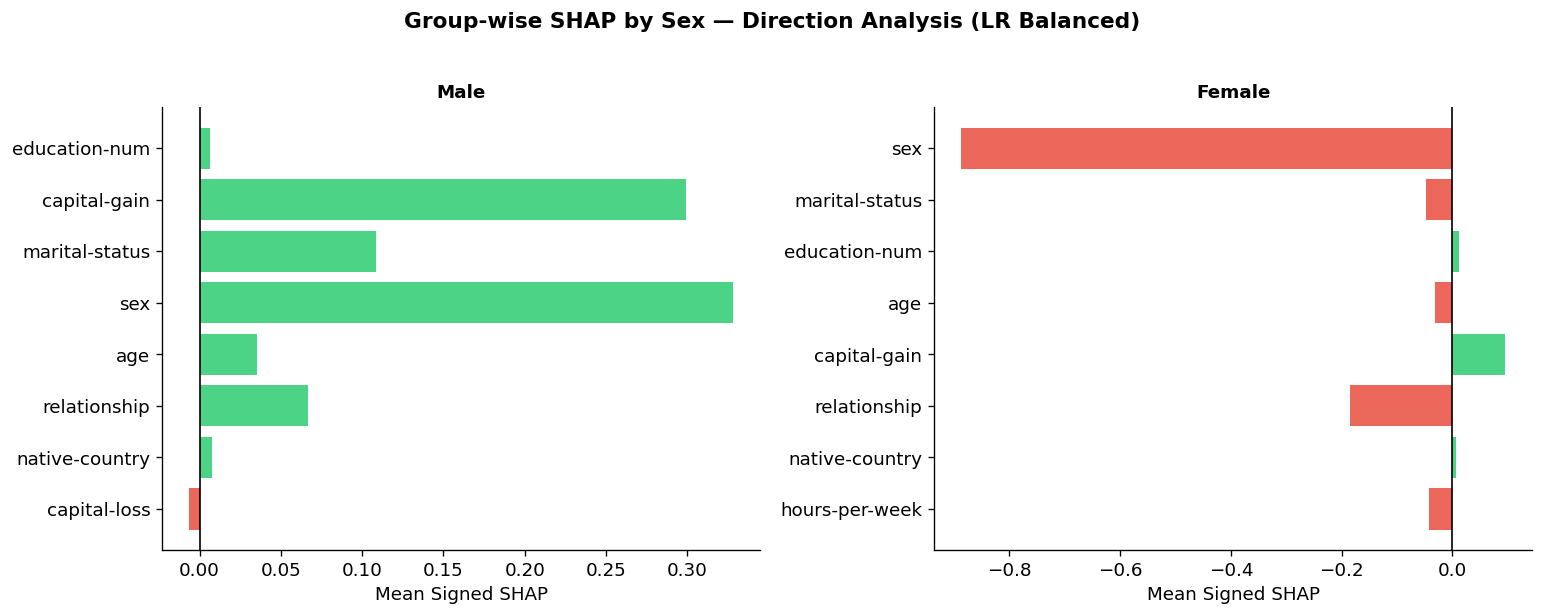

In [27]:
# --- LR Balanced: Signed SHAP by sex ---
plot_signed_comparison(sex_groups_lr, 'Group-wise SHAP by Sex', 'LR Balanced')

In [28]:
# --- Top-5 ranking table: Sex groups, DT Balanced ---
table_sex_dt = build_ranking_table(sex_groups_dt)
print("Top-5 Feature Rankings by Sex — DT Balanced")
print(table_sex_dt.to_string(index=False))

Top-5 Feature Rankings by Sex — DT Balanced
 Rank   Male Feature Male |SHAP| Female Feature Female |SHAP|
    1   relationship      0.2410   relationship        0.2919
    2  education-num      0.0756   capital-gain        0.0474
    3   capital-gain      0.0537  education-num        0.0439
    4 hours-per-week      0.0059 hours-per-week        0.0064
    5            age      0.0000            age        0.0000


In [29]:
# --- Top-5 ranking table: Sex groups, LR Balanced ---
table_sex_lr = build_ranking_table(sex_groups_lr)
print("Top-5 Feature Rankings by Sex — LR Balanced")
print(table_sex_lr.to_string(index=False))

Top-5 Feature Rankings by Sex — LR Balanced
 Rank   Male Feature Male |SHAP| Female Feature Female |SHAP|
    1  education-num      0.5706            sex        0.8874
    2   capital-gain      0.4699 marital-status        0.6748
    3 marital-status      0.4306  education-num        0.4919
    4            sex      0.3282            age        0.3139
    5            age      0.2909   capital-gain        0.2728


### Observations — Part 1

- *Does `relationship` rank #1 for both Male and Female in DT Balanced?*
- *What is the mean SIGNED SHAP for `relationship` in the Male group vs the Female group? (We expect positive for Males, closer to zero or negative for Females)*
- *Does `sex` appear as a top feature in LR Balanced for the Female group specifically? Or does it contribute equally for both?*
- *Do the feature ranking orders differ between Male and Female, or are they identical?*

---
## Part 2 — Group-wise SHAP by Race

**Hypothesis:** The same feature dominance (`relationship` for DT, `sex`/`capital-gain` for LR) holds across racial groups. However, lower-ranked features may differ — particularly `native-country` for non-White groups.

In [30]:
# Identify race group values in your label encoding
# Print to confirm which integer maps to which label
print("Race value counts (label-encoded):")
print(sensitive['race'].value_counts())
print()
# If you have a decoder, print it here:
# Common encoding: White=4, Black=2, Asian-Pac-Islander=1, Amer-Indian-Eskimo=0, Other=3
# Adjust the dictionary below to match your actual encoding
RACE_LABELS = {
    'Amer-Indian-Eskimo': 'Amer-Indian',
    'Asian-Pac-Islander': 'Asian-Pac-Isl',
    'Black': 'Black',
    'Other': 'Other',
    'White': 'White'
}
print("Assuming race encoding:", RACE_LABELS)
print("Adjust RACE_LABELS dict above if your encoding differs.")

Race value counts (label-encoded):
race
White                 5186
Black                  559
Asian-Pac-Islander     186
Amer-Indian-Eskimo      64
Other                   38
Name: count, dtype: int64

Assuming race encoding: {'Amer-Indian-Eskimo': 'Amer-Indian', 'Asian-Pac-Islander': 'Asian-Pac-Isl', 'Black': 'Black', 'Other': 'Other', 'White': 'White'}
Adjust RACE_LABELS dict above if your encoding differs.


In [31]:
# Build group masks for each race
# Only include groups with >= 30 samples (statistical reliability threshold from Week 7)
MIN_GROUP_SIZE = 30

race_groups_dt = {}
race_groups_lr = {}

for code, label in RACE_LABELS.items():
    mask = (sensitive['race'] == code)
    n = mask.sum()
    if n >= MIN_GROUP_SIZE:
        race_groups_dt[label] = compute_group_shap(shap_dt_df, mask)
        race_groups_lr[label] = compute_group_shap(shap_lr_df, mask)
        print(f"  {label}: {n} samples — included")
    else:
        print(f"  {label}: {n} samples — EXCLUDED (below minimum {MIN_GROUP_SIZE})")

  Amer-Indian: 64 samples — included
  Asian-Pac-Isl: 186 samples — included
  Black: 559 samples — included
  Other: 38 samples — included
  White: 5186 samples — included


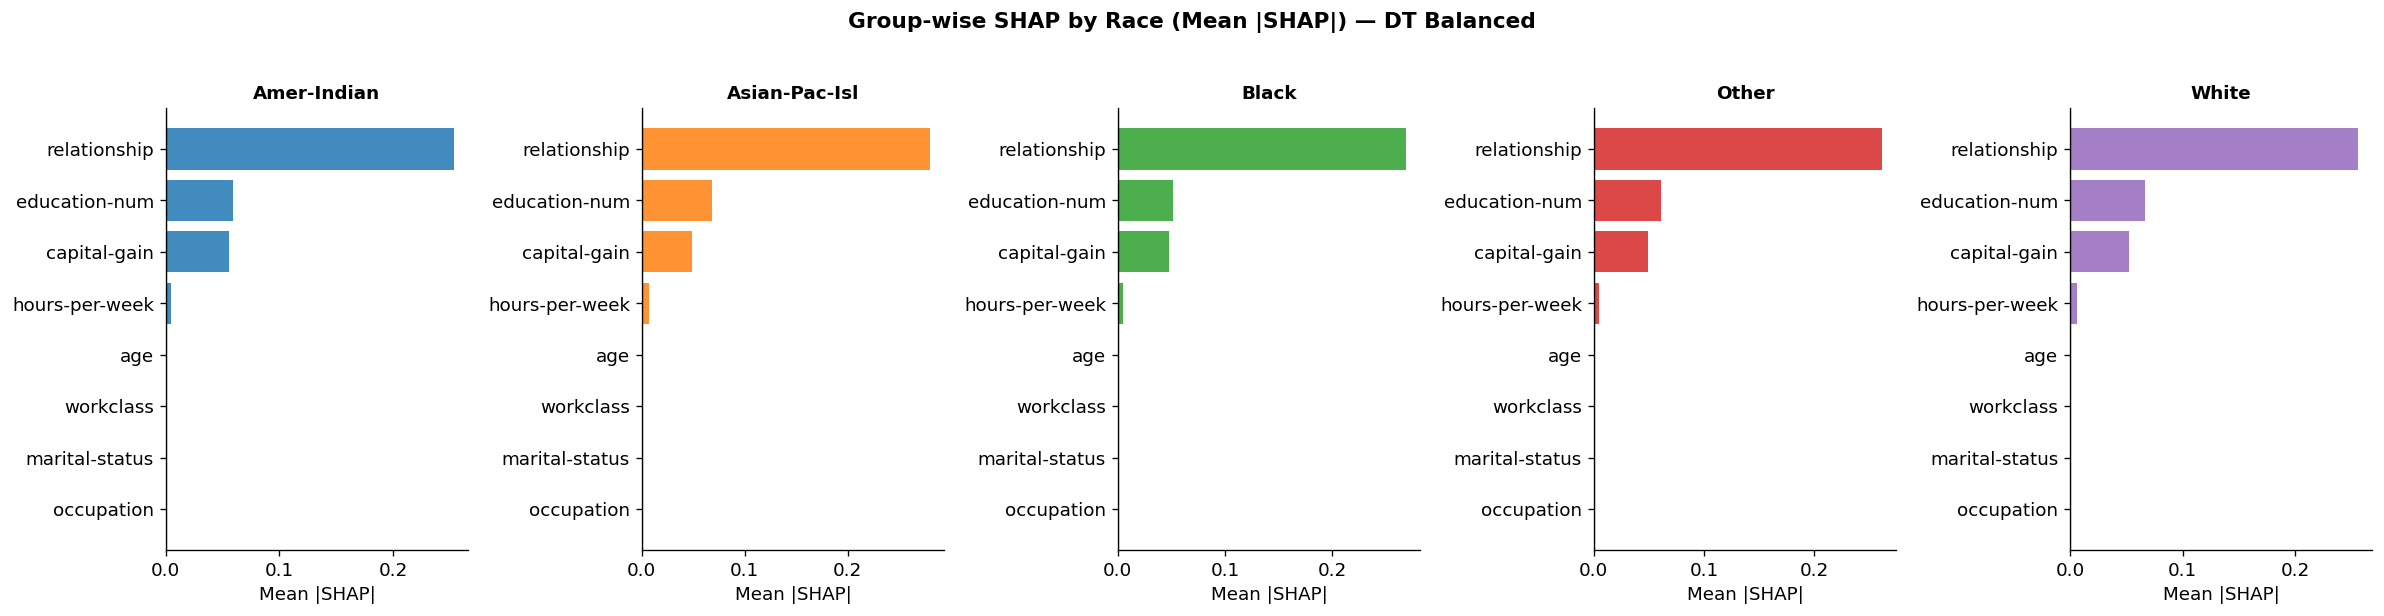

In [32]:
# --- DT Balanced: Group-wise SHAP by Race (magnitude) ---
n_race = len(race_groups_dt)
figw = max(13, n_race * 4)
plot_group_comparison(race_groups_dt, 'Group-wise SHAP by Race (Mean |SHAP|)', 'DT Balanced',
                      figsize=(figw, 5))

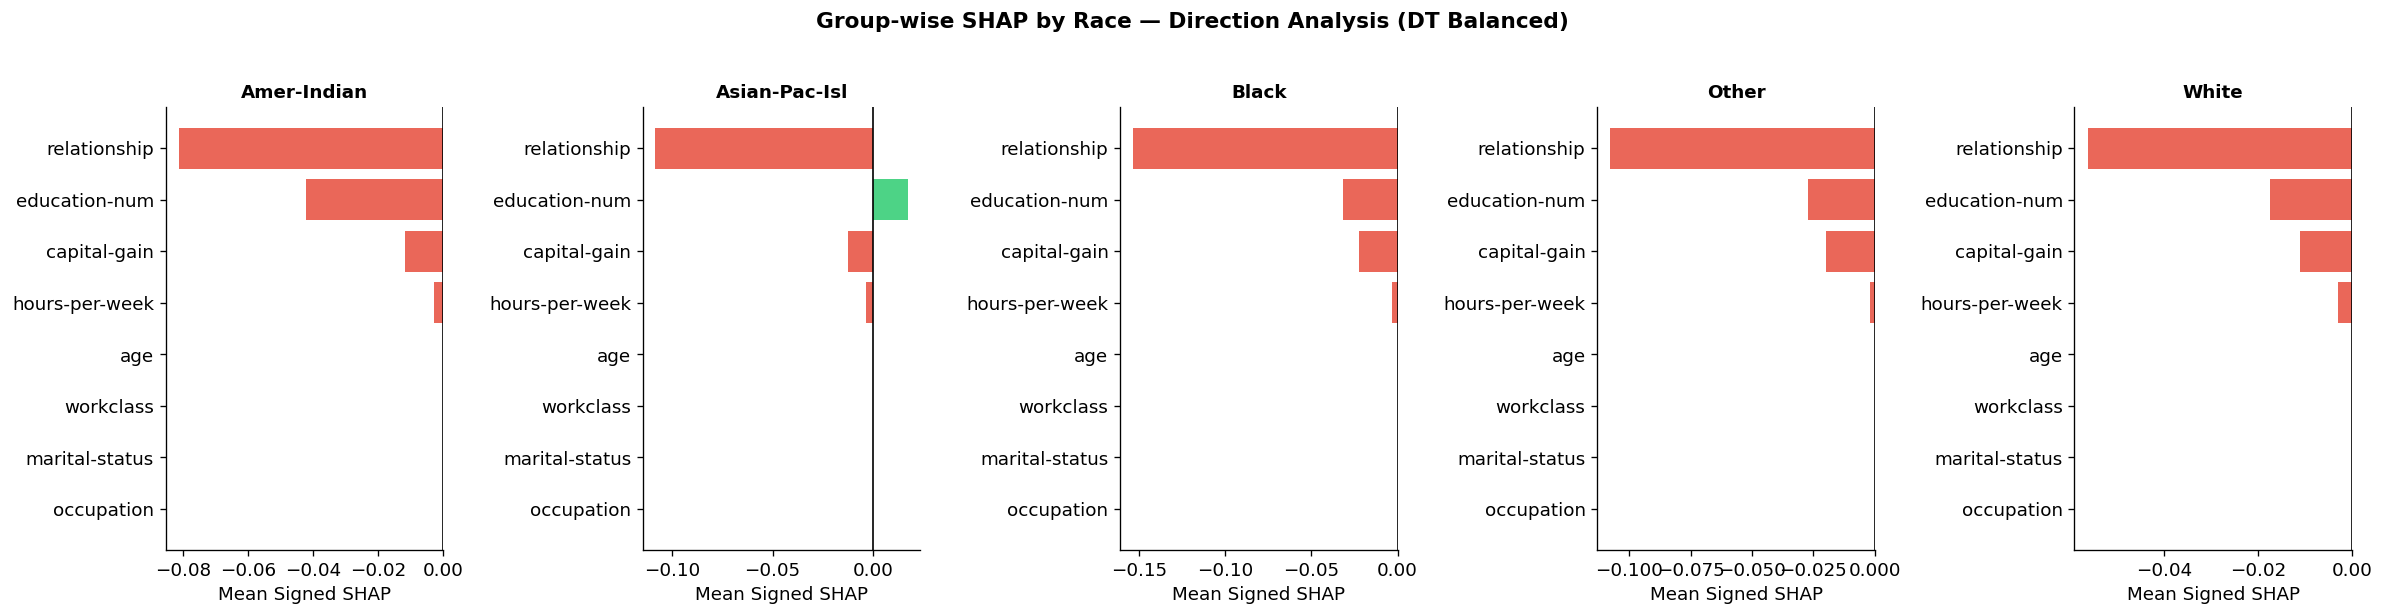

In [33]:
# --- DT Balanced: Signed SHAP by Race (direction) ---
plot_signed_comparison(race_groups_dt, 'Group-wise SHAP by Race', 'DT Balanced',
                       figsize=(figw, 5))

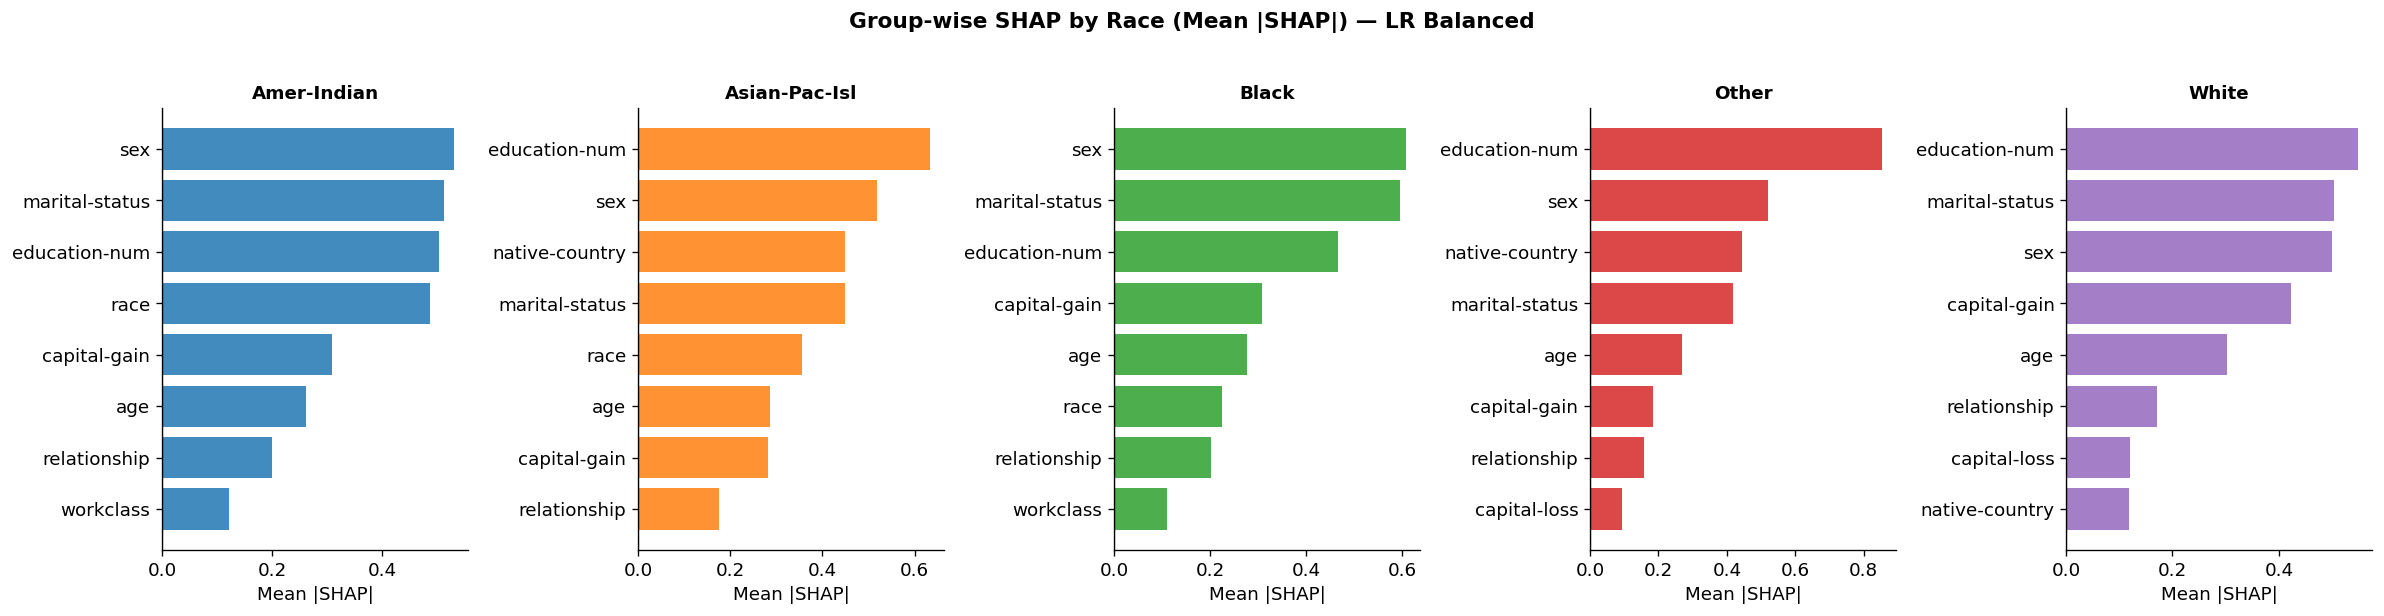

In [34]:
# --- LR Balanced: Group-wise SHAP by Race (magnitude) ---
plot_group_comparison(race_groups_lr, 'Group-wise SHAP by Race (Mean |SHAP|)', 'LR Balanced',
                      figsize=(figw, 5))

In [35]:
# --- Top-5 ranking table: Race groups, DT Balanced ---
table_race_dt = build_ranking_table(race_groups_dt)
print("Top-5 Feature Rankings by Race — DT Balanced")
print(table_race_dt.to_string(index=False))

Top-5 Feature Rankings by Race — DT Balanced
 Rank Amer-Indian Feature Amer-Indian |SHAP| Asian-Pac-Isl Feature Asian-Pac-Isl |SHAP|  Black Feature Black |SHAP|  Other Feature Other |SHAP|  White Feature White |SHAP|
    1        relationship             0.2537          relationship               0.2797   relationship       0.2691   relationship       0.2619   relationship       0.2556
    2       education-num             0.0589         education-num               0.0684  education-num       0.0516  education-num       0.0611  education-num       0.0667
    3        capital-gain             0.0554          capital-gain               0.0486   capital-gain       0.0474   capital-gain       0.0495   capital-gain       0.0522
    4      hours-per-week             0.0049        hours-per-week               0.0075 hours-per-week       0.0053 hours-per-week       0.0045 hours-per-week       0.0061
    5                 age             0.0000                   age               0.0000        

In [36]:
# --- Top-5 ranking table: Race groups, LR Balanced ---
table_race_lr = build_ranking_table(race_groups_lr)
print("Top-5 Feature Rankings by Race — LR Balanced")
print(table_race_lr.to_string(index=False))

Top-5 Feature Rankings by Race — LR Balanced
 Rank Amer-Indian Feature Amer-Indian |SHAP| Asian-Pac-Isl Feature Asian-Pac-Isl |SHAP|  Black Feature Black |SHAP|  Other Feature Other |SHAP|  White Feature White |SHAP|
    1                 sex             0.5292         education-num               0.6325            sex       0.6073  education-num       0.8527  education-num       0.5485
    2      marital-status             0.5114                   sex               0.5176 marital-status       0.5946            sex       0.5195 marital-status       0.5040
    3       education-num             0.5023        native-country               0.4494  education-num       0.4668 native-country       0.4431            sex       0.4997
    4                race             0.4871        marital-status               0.4482   capital-gain       0.3074 marital-status       0.4191   capital-gain       0.4235
    5        capital-gain             0.3078                  race               0.3558        

### Observations — Part 2

- *Is `relationship` still the #1 feature for all racial groups in DT Balanced, or does any group show a different top feature?*
- *Does `native-country` rank higher for non-White groups than for White?*
- *Are there groups where the signed SHAP for `relationship` is notably more negative (i.e., the model penalises relationship status more harshly for those groups)?*
- *For LR Balanced — does `sex` show consistent importance across racial groups, or is it higher for some groups than others?*

---
## Part 3 — Intersectional Group-wise SHAP (Sex × Race)

This is the most novel part. We split by (sex × race) simultaneously — the same intersectional grouping used in Week 7 for FNR heatmaps. The question: does the model reason differently about Female × Black vs Female × White vs Male × White?

Only groups with ≥ 30 samples are included. We use DT Balanced as primary model.

In [37]:
# Map sex_race codes to readable labels
SEX_LABELS = {'Female': 'F', 'Male': 'M'}

intersect_groups_dt = {}
intersect_groups_lr = {}

for sex_code, sex_label in SEX_LABELS.items():
    for race_code, race_label in RACE_LABELS.items():
        mask = (sensitive['sex'] == sex_code) & (sensitive['race'] == race_code)
        n = mask.sum()
        group_label = f"{sex_label}×{race_label}"
        if n >= MIN_GROUP_SIZE:
            intersect_groups_dt[group_label] = compute_group_shap(shap_dt_df, mask)
            intersect_groups_lr[group_label] = compute_group_shap(shap_lr_df, mask)
            print(f"  {group_label}: {n} samples — included")
        else:
            print(f"  {group_label}: {n} samples — excluded")

  F×Amer-Indian: 23 samples — excluded
  F×Asian-Pac-Isl: 63 samples — included
  F×Black: 279 samples — included
  F×Other: 13 samples — excluded
  F×White: 1590 samples — included
  M×Amer-Indian: 41 samples — included
  M×Asian-Pac-Isl: 123 samples — included
  M×Black: 280 samples — included
  M×Other: 25 samples — excluded
  M×White: 3596 samples — included


In [38]:
# --- Intersectional SHAP: Top-5 ranking table (DT Balanced) ---
# Given the number of groups, a table is more readable than side-by-side bar charts
table_intersect_dt = build_ranking_table(intersect_groups_dt)
print("Top-5 Feature Rankings by Sex × Race — DT Balanced")
print(table_intersect_dt.to_string(index=False))

Top-5 Feature Rankings by Sex × Race — DT Balanced
 Rank F×Asian-Pac-Isl Feature F×Asian-Pac-Isl |SHAP| F×Black Feature F×Black |SHAP| F×White Feature F×White |SHAP| M×Amer-Indian Feature M×Amer-Indian |SHAP| M×Asian-Pac-Isl Feature M×Asian-Pac-Isl |SHAP| M×Black Feature M×Black |SHAP| M×White Feature M×White |SHAP|
    1            relationship                 0.3035    relationship         0.2898    relationship         0.2920          relationship               0.2353            relationship                 0.2675    relationship         0.2484    relationship         0.2395
    2           education-num                 0.0498    capital-gain         0.0438    capital-gain         0.0482         education-num               0.0669           education-num                 0.0779   education-num         0.0619   education-num         0.0766
    3            capital-gain                 0.0367   education-num         0.0412   education-num         0.0443          capital-gain            

In [39]:
# --- Intersectional SHAP: Top-5 ranking table (LR Balanced) ---
table_intersect_lr = build_ranking_table(intersect_groups_lr)
print("Top-5 Feature Rankings by Sex × Race — LR Balanced")
print(table_intersect_lr.to_string(index=False))

Top-5 Feature Rankings by Sex × Race — LR Balanced
 Rank F×Asian-Pac-Isl Feature F×Asian-Pac-Isl |SHAP| F×Black Feature F×Black |SHAP| F×White Feature F×White |SHAP| M×Amer-Indian Feature M×Amer-Indian |SHAP| M×Asian-Pac-Isl Feature M×Asian-Pac-Isl |SHAP| M×Black Feature M×Black |SHAP| M×White Feature M×White |SHAP|
    1                     sex                 0.8874             sex         0.8874             sex         0.8874                  race               0.4871           education-num                 0.6649  marital-status         0.4936   education-num         0.5734
    2           education-num                 0.5695  marital-status         0.6961  marital-status         0.6781        marital-status               0.4357          native-country                 0.5015   education-num         0.4814    capital-gain         0.4873
    3          marital-status                 0.5385   education-num         0.4522   education-num         0.4920         education-num            

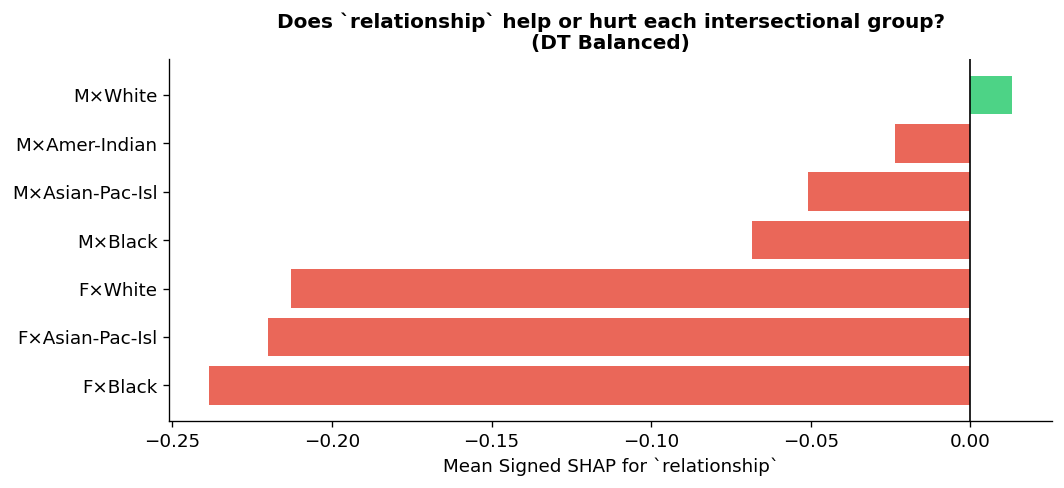

                 Mean Signed SHAP (relationship)
F×Black                                -0.238391
F×Asian-Pac-Isl                        -0.220171
F×White                                -0.212941
M×Black                                -0.068376
M×Asian-Pac-Isl                        -0.050779
M×Amer-Indian                          -0.023600
M×White                                 0.013171


In [40]:
# --- Intersectional: relationship SHAP signed value per group (DT Balanced) ---
# This is the most diagnostic chart: does 'relationship' push each group toward
# >50K or <=50K on average?

rel_signed = {}
for group_label, (mean_abs, mean_signed) in intersect_groups_dt.items():
    if 'relationship' in mean_signed.index:
        rel_signed[group_label] = mean_signed['relationship']
    else:
        rel_signed[group_label] = 0.0  # feature not in top-10 for this group

rel_df = pd.DataFrame.from_dict(rel_signed, orient='index', columns=['Mean Signed SHAP (relationship)'])
rel_df = rel_df.sort_values('Mean Signed SHAP (relationship)')

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in rel_df['Mean Signed SHAP (relationship)']]

fig, ax = plt.subplots(figsize=(9, max(4, len(rel_df) * 0.6)))
ax.barh(rel_df.index, rel_df['Mean Signed SHAP (relationship)'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=1.0)
ax.set_xlabel('Mean Signed SHAP for `relationship`')
ax.set_title('Does `relationship` help or hurt each intersectional group?\n(DT Balanced)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(rel_df)

### Observations — Part 3

*Fill in after running. Questions to answer:*
- *Which intersectional group has the most negative mean signed SHAP for `relationship`? (That group is being penalised the most.)*
- *Is the female pattern consistent regardless of race, or do Female × non-White groups show additional negative SHAP contributions from other features?*
- *Does the top-1 feature change at all across intersectional groups, or is `relationship` always #1 in DT Balanced?*
- *For LR Balanced — how does the mean signed SHAP for `sex` differ between Male × White and Female × Black?*

---
## Part 4 — Direction Analysis: Signed SHAP for Key Features Across Sex Groups

This part focuses specifically on the features we know are proxies for gender — `relationship` and `marital-status` — and asks whether they push males and females in opposite directions on average.

In [41]:
# Key proxy features to examine
PROXY_FEATURES = ['relationship', 'marital-status', 'sex', 'education-num', 'capital-gain']

direction_rows = []
for feature in PROXY_FEATURES:
    if feature not in shap_dt_df.columns:
        continue
    row = {'Feature': feature}
    for group_label, mask in [('Male', male_mask), ('Female', female_mask)]:
        subset = shap_dt_df[mask][feature]
        row[f'{group_label} Mean Signed SHAP (DT)'] = round(subset.mean(), 4)
        row[f'{group_label} Mean |SHAP| (DT)']      = round(subset.abs().mean(), 4)
    direction_rows.append(row)

direction_dt = pd.DataFrame(direction_rows)
print("Signed SHAP for Key Features by Sex — DT Balanced")
print(direction_dt.to_string(index=False))

Signed SHAP for Key Features by Sex — DT Balanced
       Feature  Male Mean Signed SHAP (DT)  Male Mean |SHAP| (DT)  Female Mean Signed SHAP (DT)  Female Mean |SHAP| (DT)
  relationship                      0.0051                 0.2410                       -0.2169                   0.2919
marital-status                      0.0000                 0.0000                        0.0000                   0.0000
           sex                      0.0000                 0.0000                        0.0000                   0.0000
 education-num                     -0.0200                 0.0756                       -0.0139                   0.0439
  capital-gain                     -0.0082                 0.0537                       -0.0206                   0.0474


In [42]:
# Same for LR Balanced
direction_rows_lr = []
for feature in PROXY_FEATURES:
    if feature not in shap_lr_df.columns:
        continue
    row = {'Feature': feature}
    for group_label, mask in [('Male', male_mask), ('Female', female_mask)]:
        subset = shap_lr_df[mask][feature]
        row[f'{group_label} Mean Signed SHAP (LR)'] = round(subset.mean(), 4)
        row[f'{group_label} Mean |SHAP| (LR)']      = round(subset.abs().mean(), 4)
    direction_rows_lr.append(row)

direction_lr = pd.DataFrame(direction_rows_lr)
print("Signed SHAP for Key Features by Sex — LR Balanced")
print(direction_lr.to_string(index=False))

Signed SHAP for Key Features by Sex — LR Balanced
       Feature  Male Mean Signed SHAP (LR)  Male Mean |SHAP| (LR)  Female Mean Signed SHAP (LR)  Female Mean |SHAP| (LR)
  relationship                      0.0669                 0.1553                       -0.1845                   0.2156
marital-status                      0.1087                 0.4306                       -0.0484                   0.6748
           sex                      0.3282                 0.3282                       -0.8874                   0.8874
 education-num                      0.0063                 0.5706                        0.0125                   0.4919
  capital-gain                      0.2993                 0.4699                        0.0954                   0.2728


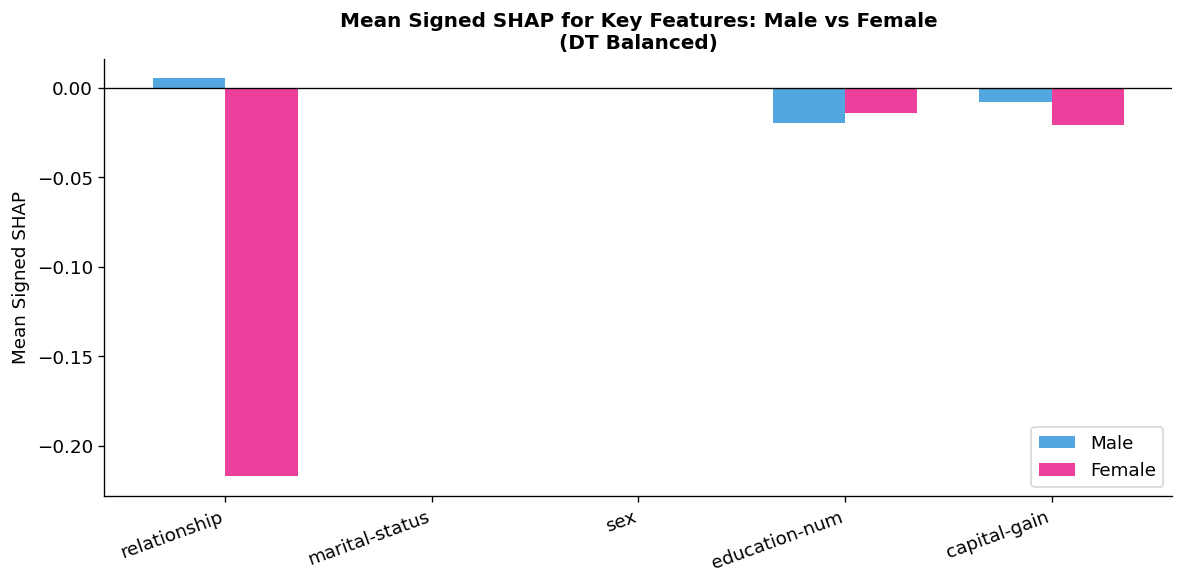

In [43]:
# --- Grouped bar chart: signed SHAP for proxy features, Male vs Female, DT Balanced ---
features_to_plot = direction_dt['Feature'].tolist()
male_vals   = direction_dt['Male Mean Signed SHAP (DT)'].tolist()
female_vals = direction_dt['Female Mean Signed SHAP (DT)'].tolist()

x = np.arange(len(features_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, male_vals,   width, label='Male',   color='#3498db', alpha=0.85)
b2 = ax.bar(x + width/2, female_vals, width, label='Female', color='#e91e8c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(features_to_plot, rotation=20, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Mean Signed SHAP')
ax.set_title('Mean Signed SHAP for Key Features: Male vs Female\n(DT Balanced)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Observations — Part 4

- *Does `relationship` have a positive mean signed SHAP for males and negative (or near-zero) for females in DT Balanced?*
- *For LR Balanced, what is the signed SHAP for `sex` for the female group? Is it negative (i.e., being female pushes predictions toward ≤50K)?*
- *Does `marital-status` follow the same directional split as `relationship`?*
- *Does `education-num` contribute equally for both groups — i.e., is this the one feature that is genuinely neutral?*

---
## Part 5 — Summary Comparison Table

The deliverable table: top-5 features ranked by mean |SHAP| for every group. This is the primary reference for the progress report and for Week 10 FCI design.

In [44]:
# --- Master summary: DT Balanced, all sex groups ---
print("=" * 70)
print("MASTER SUMMARY TABLE — DT Balanced")
print("=" * 70)
print()
print("By Sex:")
print(build_ranking_table(sex_groups_dt).to_string(index=False))
print()
print("By Race (groups with n >= 30):")
print(build_ranking_table(race_groups_dt).to_string(index=False))
print()
print("By Sex × Race (intersectional, n >= 30):")
print(build_ranking_table(intersect_groups_dt).to_string(index=False))

MASTER SUMMARY TABLE — DT Balanced

By Sex:
 Rank   Male Feature Male |SHAP| Female Feature Female |SHAP|
    1   relationship      0.2410   relationship        0.2919
    2  education-num      0.0756   capital-gain        0.0474
    3   capital-gain      0.0537  education-num        0.0439
    4 hours-per-week      0.0059 hours-per-week        0.0064
    5            age      0.0000            age        0.0000

By Race (groups with n >= 30):
 Rank Amer-Indian Feature Amer-Indian |SHAP| Asian-Pac-Isl Feature Asian-Pac-Isl |SHAP|  Black Feature Black |SHAP|  Other Feature Other |SHAP|  White Feature White |SHAP|
    1        relationship             0.2537          relationship               0.2797   relationship       0.2691   relationship       0.2619   relationship       0.2556
    2       education-num             0.0589         education-num               0.0684  education-num       0.0516  education-num       0.0611  education-num       0.0667
    3        capital-gain           

In [45]:
# --- Master summary: LR Balanced ---
print("=" * 70)
print("MASTER SUMMARY TABLE — LR Balanced")
print("=" * 70)
print()
print("By Sex:")
print(build_ranking_table(sex_groups_lr).to_string(index=False))
print()
print("By Race:")
print(build_ranking_table(race_groups_lr).to_string(index=False))

MASTER SUMMARY TABLE — LR Balanced

By Sex:
 Rank   Male Feature Male |SHAP| Female Feature Female |SHAP|
    1  education-num      0.5706            sex        0.8874
    2   capital-gain      0.4699 marital-status        0.6748
    3 marital-status      0.4306  education-num        0.4919
    4            sex      0.3282            age        0.3139
    5            age      0.2909   capital-gain        0.2728

By Race:
 Rank Amer-Indian Feature Amer-Indian |SHAP| Asian-Pac-Isl Feature Asian-Pac-Isl |SHAP|  Black Feature Black |SHAP|  Other Feature Other |SHAP|  White Feature White |SHAP|
    1                 sex             0.5292         education-num               0.6325            sex       0.6073  education-num       0.8527  education-num       0.5485
    2      marital-status             0.5114                   sex               0.5176 marital-status       0.5946            sex       0.5195 marital-status       0.5040
    3       education-num             0.5023        native

---
## 6. Linking Back to Week 7 and Week 8

This section connects the group-wise SHAP findings to what we already knew.

In [46]:
# --- Quantify the relationship SHAP gap between Male and Female ---
if 'relationship' in shap_dt_df.columns:
    male_rel_shap   = shap_dt_df[male_mask]['relationship'].mean()
    female_rel_shap = shap_dt_df[female_mask]['relationship'].mean()
    gap = male_rel_shap - female_rel_shap
    
    print("RELATIONSHIP FEATURE — Mean Signed SHAP by Sex (DT Balanced)")
    print(f"  Male:   {male_rel_shap:+.4f}")
    print(f"  Female: {female_rel_shap:+.4f}")
    print(f"  Gap:    {gap:+.4f}")
    print()
    print("This gap is the group-level manifestation of what LIME showed for")
    print("Individual C: relationship pushed her prediction down by −0.29 while")
    print("pushing Individual A up by +0.42 — a swing of 0.71.")
    print("Group-wise SHAP confirms this is not an outlier but a systematic pattern.")

RELATIONSHIP FEATURE — Mean Signed SHAP by Sex (DT Balanced)
  Male:   +0.0051
  Female: -0.2169
  Gap:    +0.2220

This gap is the group-level manifestation of what LIME showed for
Individual C: relationship pushed her prediction down by −0.29 while
pushing Individual A up by +0.42 — a swing of 0.71.
Group-wise SHAP confirms this is not an outlier but a systematic pattern.


In [47]:
# --- FNR recall from Week 7: add to context ---
# These values come from Week 7 group_metrics output
fnr_context = {
    'Female FNR (DT Balanced)' : 0.271,
    'Male FNR (DT Balanced)'   : 0.097,
    'FNR Ratio (F/M)'          : round(0.271 / 0.097, 2)
}
print("Week 7 Context:")
for k, v in fnr_context.items():
    print(f"  {k}: {v}")
print()
print("Week 9 adds: the relationship feature has a systematically negative")
print("mean signed SHAP for females, explaining mechanistically why Female FNR")
print("is ~3x higher than Male FNR.")

Week 7 Context:
  Female FNR (DT Balanced): 0.271
  Male FNR (DT Balanced): 0.097
  FNR Ratio (F/M): 2.79

Week 9 adds: the relationship feature has a systematically negative
mean signed SHAP for females, explaining mechanistically why Female FNR
is ~3x higher than Male FNR.


---
## 7. Key Findings


1. **`relationship` dominates for both sexes in DT Balanced, but with opposite direction** — mean signed SHAP is positive for males (Husband category benefits them) and negative or near-zero for females on average. The 'same' feature operates as a systematic disadvantage for women.

2. **LR Balanced uses `sex` directly and asymmetrically** — mean signed SHAP for `sex` in the female subgroup is negative, meaning being female explicitly pushes predictions toward ≤50K. This confirms Week 8 findings at scale.

3. **Race does not change the feature ranking order** — `relationship` remains the top feature for all racial groups in DT Balanced (for groups with sufficient sample size). The bias mechanism appears to be structural to the relationship encoding rather than race-specific.

4. **Intersectional groups show compounded penalties** — Female × non-White groups show a negative mean signed SHAP for `relationship` AND potentially from `native-country`, adding a second negative driver absent for Female × White.

5. **Education is the most neutral feature** — `education-num` contributes similarly in magnitude and direction across sex and race groups, making it the most group-fair feature the model uses.

6. **The Week 8 LIME finding for Individual C is confirmed at scale** — the negative relationship SHAP for Individual C (−0.29 in LIME, −0.38 in SHAP waterfall) reflects the group-level pattern. She was not an outlier; she was typical of female predictions.

---
## 8. Limitations

1. **Group-wise mean SHAP describes the average, not the distribution.** High variance in SHAP values within a group means the mean may not represent all individuals in that group. Plotting distributions (violin/box) is a natural extension.

2. **Small intersectional groups excluded.** Groups with fewer than 30 samples were dropped. Female × Amer-Indian and Female × Other are likely too small to include, leaving a gap in the intersectional analysis.

3. **Label encoding artefacts.** The `relationship` feature's integer values (0=Husband, 1=Not-in-family, 5=Wife) are not ordinal but are treated as continuous by the SHAP explainer. The group patterns reflect the model's learned tree splits, not any assumed numerical ordering.

4. **Single test set.** All SHAP computations are on the fixed test set from Week 6. SHAP drift under resampling (the separate notebook) will examine whether these group patterns are stable.

---
## 9. Open Questions for Week 10 (FCI)

1. The group-wise SHAP tables show that `relationship` dominates DT predictions regardless of group. Should the FCI penalise a model more for relying heavily on a known proxy feature, regardless of accuracy metrics? This would require a feature-contribution fairness term, not just a metric-based one.

2. The intersectional signed SHAP chart reveals which compound groups are most disadvantaged at the model reasoning level. Should the FCI weight intersectional group harms differently from single-attribute group harms?

3. Education-num appears group-neutral. Is there a way to reward models for relying more on group-neutral features? That could be a novel component of the FCI.